2.1 

给定字符序列 `"ababc"`，词汇表 $V=\{\text{a},\text{b},\text{c}\}$。统计相邻转移：

- a→b 出现 2 次（位置1→2，3→4）
- b→a 出现 1 次（位置2→3）
- b→c 出现 1 次（位置4→5）
- 其他转移 0 次

转移计数矩阵（行→列）：

|   | a | b | c |
|---|---|---|---|
| a | 0 | 2 | 0 |
| b | 1 | 0 | 1 |
| c | 0 | 0 | 0 |

拉普拉斯平滑（加1）估计：
$$
p(y \mid x) = \frac{\text{count}(x \to y) + 1}{\sum_{y' \in V} \left( \text{count}(x \to y') + 1 \right)}
            = \frac{\text{count}(x \to y) + 1}{\text{count}(x \to \cdot) + |V|}
$$

**计算 $p(\text{a} \mid \text{b})$**：
$$
p(\text{a} \mid \text{b}) = \frac{1+1}{2+3} = \frac{2}{5} = 0.4
$$

**计算 $p(\text{c} \mid \text{b})$**：
$$
p(\text{c} \mid \text{b}) = \frac{1+1}{2+3} = \frac{2}{5} = 0.4
$$



In [8]:
# 2.2
import re
from collections import Counter

def preprocess_text(text, n):
    """
    文本预处理并生成自回归特征-标签对。
    参数:
        text (str): 输入文本
        n (int): 窗口大小（特征词数）
    返回:
        word2id (dict): 词到整数ID的映射
        features (list of list): 每个样本的特征词列表
        labels (list): 每个样本的标签词（若无则为None）
    """
    # 1. 转小写，去除非字母和空格的字符
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # 保留字母和空格
    # 2. 按空格分词，过滤空字符串
    words = [w for w in text.split() if w]
    
    # 3. 构建词汇表：按频率降序分配ID，从0开始
    freq = Counter(words)
    sorted_vocab = sorted(freq.items(), key=lambda x: x[1], reverse=True)
    word2id = {word: idx for idx, (word, _) in enumerate(sorted_vocab)}
    
    # 4. 滑动窗口生成特征和标签
    features = []
    labels = []
    L = len(words)
    for i in range(L - n + 1):   # 包含最后一个窗口（可能无标签）
        feat = words[i:i+n]
        if i + n < L:
            label = words[i+n]
        else:
            label = None
        features.append(feat)
        labels.append(label)
    
    return word2id, features, labels

# 测试
text = "The time machine"
n = 2
vocab, feats, labs = preprocess_text(text, n)
print("词汇表:", vocab)
print("特征列表:", feats)
print("标签列表:", labs)

词汇表: {'the': 0, 'time': 1, 'machine': 2}
特征列表: [['the', 'time'], ['time', 'machine']]
标签列表: ['machine', None]


3.1 

模型定义：
$$
h_t = W_{hh} h_{t-1} + W_{hx} x_t, \qquad o_t = W_{oh} h_t
$$
损失函数：
$$
L = \frac{1}{2} \sum_{t=1}^{T} (o_t - y_t)^2
$$

定义 $\delta_t = \partial L / \partial h_t$，则反向递推：
$$
\delta_t = W_{oh}^T (o_t - y_t) + W_{hh}^T \delta_{t+1}, \qquad \delta_{T+1} = 0
$$
展开得：
$$
\delta_t = \sum_{k=t}^{T} (W_{hh}^T)^{k-t} W_{oh}^T (o_k - y_k)
$$

损失对 $W_{hh}$ 的梯度：
$$
\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \delta_t h_{t-1}^T
$$
代入展开式：
$$
\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \sum_{k=t}^{T} 
    (W_{hh}^T)^{k-t} W_{oh}^T (o_k - y_k) h_{t-1}^T
$$

梯度消失/爆炸条件：梯度中含 $(W_{hh}^T)^{k-t}$。若 $W_{hh}$ 的谱半径 $\rho(W_{hh}) > 1$，则随时间间隔增大梯度指数增长（爆炸）；若 $\rho(W_{hh}) < 1$，则指数衰减（消失）。若 $\rho(W_{hh}) \approx 1$，梯度可稳定传播。

In [9]:
# 3.2
import numpy as np

def rnn_cell_forward(x_t, prev_h, W_xh, W_hh, b_h):
    """
    前向传播
    x_t: (batch, input_size)
    prev_h: (batch, hidden_size)
    W_xh: (input_size, hidden_size)
    W_hh: (hidden_size, hidden_size)
    b_h: (hidden_size,)
    返回: h_t, cache (用于反向传播)
    """
    h_t = np.tanh(prev_h @ W_hh + x_t @ W_xh + b_h)
    cache = (x_t, prev_h, W_xh, W_hh, b_h, h_t)
    return h_t, cache

def rnn_cell_backward(dh_next, cache):
    """
    反向传播，已知 dh_next = dL/dh_t
    返回: dx_t, dh_prev, dW_xh, dW_hh, db_h
    """
    x_t, prev_h, W_xh, W_hh, b_h, h_t = cache
    # tanh导数 = 1 - tanh^2
    dtanh = dh_next * (1 - h_t**2)
    
    # 计算梯度
    dx_t = dtanh @ W_xh.T
    dh_prev = dtanh @ W_hh.T
    dW_xh = x_t.T @ dtanh
    dW_hh = prev_h.T @ dtanh
    db_h = np.sum(dtanh, axis=0)   # 对batch求和
    
    return dx_t, dh_prev, dW_xh, dW_hh, db_h

# 测试（随机数据）
np.random.seed(0)
batch_size, input_size, hidden_size = 2, 3, 4
x_t = np.random.randn(batch_size, input_size)
prev_h = np.random.randn(batch_size, hidden_size)
W_xh = np.random.randn(input_size, hidden_size)
W_hh = np.random.randn(hidden_size, hidden_size)
b_h = np.random.randn(hidden_size)

h_t, cache = rnn_cell_forward(x_t, prev_h, W_xh, W_hh, b_h)
dh_next = np.random.randn(batch_size, hidden_size)
dx, dh_prev, dW_xh, dW_hh, db = rnn_cell_backward(dh_next, cache)

print("前向输出 h_t 形状:", h_t.shape)
print("dx 形状:", dx.shape)
print("dh_prev 形状:", dh_prev.shape)
print("dW_xh 形状:", dW_xh.shape)
print("dW_hh 形状:", dW_hh.shape)
print("db 形状:", db.shape)

前向输出 h_t 形状: (2, 4)
dx 形状: (2, 3)
dh_prev 形状: (2, 4)
dW_xh 形状: (3, 4)
dW_hh 形状: (4, 4)
db 形状: (4,)


4.1 

参数设定：
- 层数 $L$，每层隐藏单元数 $H$（每个方向）
- 输入维度 $D$，输出维度 $O$（忽略输出层投影）
- 包含所有全连接层的权重和偏置

每层包含前向和反向两个独立RNN。每个单向RNN的参数：
$$
\text{input\_size} \times H + H^2 + 2H
$$
其中 $2H$ 为输入偏置和隐藏偏置。

第一层输入维度为 $D$，双向参数：
$$
2 \left( D H + H^2 + 2H \right)
$$

后续层（第 $l=2$ 到 $L$）的输入为前一层的双向拼接，维度为 $2H$，每方向参数：
$$
(2H) \times H + H^2 + 2H = 3H^2 + 2H
$$
双向参数：
$$
2(3H^2 + 2H) = 6H^2 + 4H
$$

总参数：
$$
\boxed{ \text{Params} = 2(D H + H^2 + 2H) + (L-1)(6H^2 + 4H) }
$$
化简得：
$$
\boxed{ \text{Params} = 2DH + (6L-4)H^2 + 4LH }
$$


In [10]:
# 4.2
import torch
import torch.nn as nn

def bidirectional_rnn_encoder(X, hidden_dim, num_layers=1):
    """
    X: (seq_len, batch, input_dim)
    hidden_dim: 每方向隐藏维度
    返回:
        outputs: (seq_len, batch, 2*hidden_dim)  每个时间步拼接的隐藏状态
        final_state: (batch, 2*hidden_dim)       最后时间步的拼接（前向最后 + 反向最后）
    """
    seq_len, batch, input_dim = X.shape
    # 使用 PyTorch 的 RNN，bidirectional=True
    rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers,
                 batch_first=False, bidirectional=True)
    # 前向传播
    outputs, h_n = rnn(X)   # outputs: (seq_len, batch, 2*hidden_dim)
                              # h_n: (num_layers*2, batch, hidden_dim)
    # 取最后时间步的拼接：前向最后（h_n[-2]）和反向最后（h_n[-1]）
    # h_n 的最后一层的前向和反向分别是 h_n[-2] 和 h_n[-1]
    forward_last = h_n[-2, :, :]   # (batch, hidden_dim)
    backward_last = h_n[-1, :, :]  # (batch, hidden_dim)
    final_state = torch.cat([forward_last, backward_last], dim=1)  # (batch, 2*hidden_dim)
    
    return outputs, final_state

# 测试
seq_len, batch, input_dim = 5, 3, 8
hidden_dim = 4
X = torch.randn(seq_len, batch, input_dim)
outputs, final = bidirectional_rnn_encoder(X, hidden_dim)
print("outputs 形状:", outputs.shape)      # (5,3,8)
print("final_state 形状:", final.shape)    # (3,8)

outputs 形状: torch.Size([5, 3, 8])
final_state 形状: torch.Size([3, 8])


5.1 

给定中心词 $w_c$ 的词向量 $\mathbf{v}_c$，上下文词 $w_o$（正样本）的词向量 $\mathbf{u}_o$，负样本 $n_k$（$k=1,\dots,K$）的词向量 $\mathbf{u}_{n_k}$，噪声分布 $P_n(w)$。

负采样目标函数：
$$
P(D=1 \mid w_c, w_o) = \sigma(\mathbf{u}_o^T \mathbf{v}_c) = \frac{1}{1+e^{-\mathbf{u}_o^T \mathbf{v}_c}}
$$
对于负样本：
$$
P(D=0 \mid w_c, n_k) = \sigma(-\mathbf{u}_{n_k}^T \mathbf{v}_c)
$$

最小化负对数似然损失：
$$
\boxed{
\mathcal{L} = -\log \sigma(\mathbf{u}_o^T \mathbf{v}_c) - \sum_{k=1}^{K} \log \sigma(-\mathbf{u}_{n_k}^T \mathbf{v}_c)
}
$$

等价形式：
$$
\mathcal{L} = -\log \frac{1}{1+e^{-\mathbf{u}_o^T \mathbf{v}_c}} - \sum_{k} \log \frac{1}{1+e^{\mathbf{u}_{n_k}^T \mathbf{v}_c}}
$$

噪声分布采样：通常使用词频的 $3/4$ 次方分布：
$$
P_n(w) = \frac{\text{freq}(w)^{3/4}}{\sum_{w'} \text{freq}(w')^{3/4}}
$$

In [11]:
# 5.2
import numpy as np

def cbow_forward(context_indices, center_idx, W, W_out):
    """
    context_indices: list of list，每个样本是 context_size 个上下文词索引
    center_idx: list，每个样本的中心词索引
    W: (V, d) 输入嵌入矩阵
    W_out: (d, V) 输出权重矩阵
    返回: 交叉熵损失（标量）
    """
    batch_size = len(context_indices)
    V, d = W.shape
    
    losses = []
    for i in range(batch_size):
        idx_list = context_indices[i]
        embeds = W[idx_list]          # (context_size, d)
        h = np.mean(embeds, axis=0)   # (d,)
        logits = h @ W_out            # (V,)
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        loss = -np.log(probs[center_idx[i]] + 1e-12)
        losses.append(loss)
    return np.mean(losses)

# 1. 真实句子
corpus = "the time machine is great"
words = corpus.split()  # ['the', 'time', 'machine', 'is', 'great']

# 2. 构建词汇表 
word2id = {word: idx for idx, word in enumerate(set(words))}  # 注意set无序，为了可读性手动指定
# 手动指定保证一致性
word2id = {'the': 0, 'time': 1, 'machine': 2, 'is': 3, 'great': 4}
id2word = {v: k for k, v in word2id.items()}
V = len(word2id)
print("词汇表:", word2id)

# 3. 设置上下文大小 (左右各取1个词，总共2个上下文词)
context_size = 2  # 对应左右各1个
context_indices = []
center_idx = []

# 滑动窗口：跳过开头和结尾不够上下文的位置
for i in range(context_size // 2, len(words) - context_size // 2):
    left_id = word2id[words[i - 1]]
    right_id = word2id[words[i + 1]]
    center_id = word2id[words[i]]
    
    context_indices.append([left_id, right_id])
    center_idx.append(center_id)
    
    # 打印便于观察
    print(f"中心词: '{words[i]}' (ID={center_id}), 上下文: '{words[i-1]}' (ID={left_id}), '{words[i+1]}' (ID={right_id})")

print("\n生成的 context_indices:", context_indices)
print("生成的 center_idx:", center_idx)

# 4. 设置嵌入维度，随机初始化权重（实际训练时会学习）
np.random.seed(42)
d = 3
W = np.random.randn(V, d)   # (5, 3)
W_out = np.random.randn(d, V)  # (3, 5)

# 5. 计算损失
loss = cbow_forward(context_indices, center_idx, W, W_out)
print(f"\nCBOW 损失 (真实数据): {loss:.6f}")

词汇表: {'the': 0, 'time': 1, 'machine': 2, 'is': 3, 'great': 4}
中心词: 'time' (ID=1), 上下文: 'the' (ID=0), 'machine' (ID=2)
中心词: 'machine' (ID=2), 上下文: 'time' (ID=1), 'is' (ID=3)
中心词: 'is' (ID=3), 上下文: 'machine' (ID=2), 'great' (ID=4)

生成的 context_indices: [[0, 2], [1, 3], [2, 4]]
生成的 center_idx: [1, 2, 3]

CBOW 损失 (真实数据): 1.439705


6.1 

给定：
$$
Q \in \mathbb{R}^{2 \times 4},\quad K \in \mathbb{R}^{3 \times 4},\quad V \in \mathbb{R}^{3 \times 5},\quad d_k = 4
$$

取数值：
$$
Q = \begin{bmatrix}
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1
\end{bmatrix},\quad
K = \begin{bmatrix}
1 & 1 & 0 & 0 \\
0 & 0 & 1 & 1 \\
1 & 0 & 1 & 0
\end{bmatrix},\quad
V = \begin{bmatrix}
1 & 2 & 3 & 4 & 5 \\
5 & 4 & 3 & 2 & 1 \\
2 & 3 & 4 & 5 & 6
\end{bmatrix}
$$

（1）计算得分矩阵 $S = Q K^T / \sqrt{d_k} = Q K^T / 2$

先算 $Q K^T$：
$$
Q K^T = \begin{bmatrix}
1 & 1 & 2 \\
1 & 1 & 0
\end{bmatrix}
$$
因此
$$
S = \frac{1}{2} \begin{bmatrix}
1 & 1 & 2 \\
1 & 1 & 0
\end{bmatrix}
= \begin{bmatrix}
0.5 & 0.5 & 1.0 \\
0.5 & 0.5 & 0
\end{bmatrix}
$$

（2）对每行做 softmax

第一行（query 0）：
$$
\exp([0.5,0.5,1.0]) = [1.6487, 1.6487, 2.7183]
$$
归一化后：
$$
a_0 = [0.2741,\ 0.2741,\ 0.4518]
$$

第二行（query 1）：
$$
\exp([0.5,0.5,0]) = [1.6487, 1.6487, 1.0]
$$
归一化后：
$$
a_1 = [0.3837,\ 0.3837,\ 0.2326]
$$

注意力权重矩阵：
$$
A = \begin{bmatrix}
0.2741 & 0.2741 & 0.4518 \\
0.3837 & 0.3837 & 0.2326
\end{bmatrix}
$$

（3）加权求和 $O = A \cdot V$

$V$ 的三行分别为：
$$
v_1 = [1,2,3,4,5],\quad v_2 = [5,4,3,2,1],\quad v_3 = [2,3,4,5,6]
$$

第一行输出：
$$
O_0 = 0.2741 v_1 + 0.2741 v_2 + 0.4518 v_3
= [2.5482,\ 3.0000,\ 3.4518,\ 3.9036,\ 4.3554]
$$

第二行输出：
$$
O_1 = 0.3837 v_1 + 0.3837 v_2 + 0.2326 v_3
= [2.7674,\ 3.0000,\ 3.2326,\ 3.4652,\ 3.6978]
$$

最终输出矩阵：
$$
\boxed{
O \approx \begin{bmatrix}
2.5482 & 3.0000 & 3.4518 & 3.9036 & 4.3554 \\
2.7674 & 3.0000 & 3.2326 & 3.4652 & 3.6978
\end{bmatrix}
}
$$

输入 X 形状: torch.Size([5, 1, 4])
输出 output 形状: torch.Size([5, 1, 4])
注意力权重形状: torch.Size([1, 2, 5, 5])


d:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\33669\AppData\Local\Temp\ipykernel_27252\92518992.py:88: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE

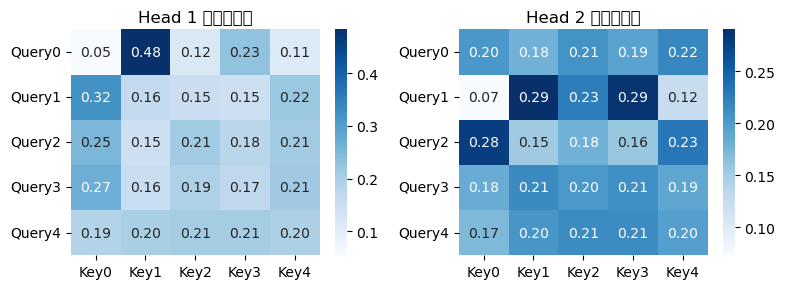

d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu San

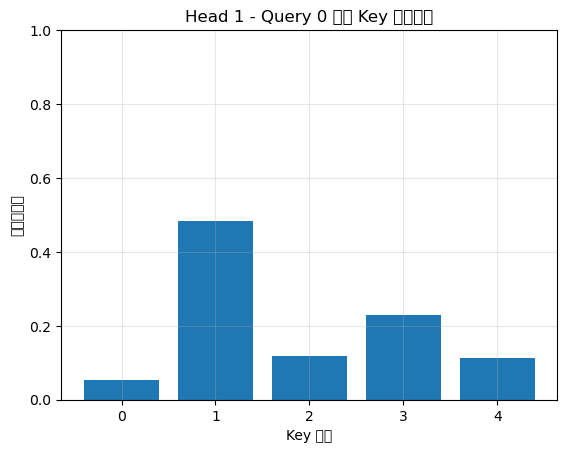

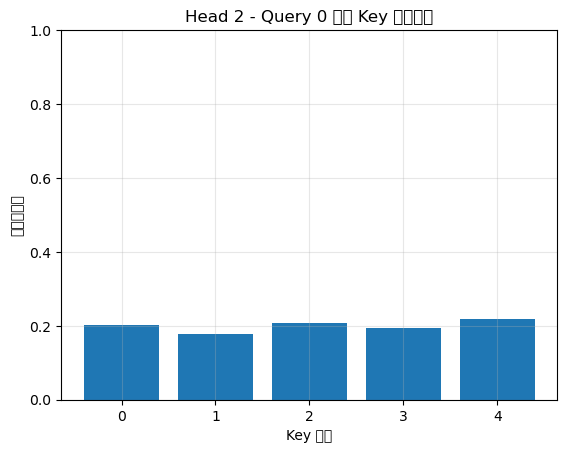

In [ ]:
# 6.2 
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 定义多头注意力模块 
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # 线性投影层（无偏置）
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, X, return_attn=False):
        """
        X: (seq_len, batch, d_model)
        return_attn: 若为True，额外返回注意力权重 (batch, num_heads, seq_len, seq_len)
        """
        seq_len, batch, _ = X.shape

        # 线性投影
        Q = self.W_q(X)  # (seq_len, batch, d_model)
        K = self.W_k(X)
        V = self.W_v(X)

        # 分割为多头并调整维度
        # (seq_len, batch, num_heads, d_k) -> (batch, num_heads, seq_len, d_k)
        Q = Q.view(seq_len, batch, self.num_heads, self.d_k).transpose(0, 1).transpose(1, 2)
        K = K.view(seq_len, batch, self.num_heads, self.d_k).transpose(0, 1).transpose(1, 2)
        V = V.view(seq_len, batch, self.num_heads, self.d_k).transpose(0, 1).transpose(1, 2)

        # 缩放点积注意力
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)  # (batch, heads, seq, seq)
        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, V)  # (batch, heads, seq, d_k)

        # 合并多头并恢复原始形状
        context = context.transpose(1, 2).contiguous().view(batch, seq_len, self.d_model).transpose(0, 1)  # (seq, batch, d_model)
        output = self.W_o(context)

        if return_attn:
            return output, attn_weights
        else:
            return output


#  2. 测试与可视化 
if __name__ == "__main__":
    # 设置参数
    d_model = 4
    num_heads = 2
    seq_len = 5
    batch = 1  # 单样本便于观察

    # 固定随机种子保证可复现
    torch.manual_seed(42)
    X = torch.randn(seq_len, batch, d_model)

    # 实例化模型并计算输出，同时获取注意力权重
    model = MultiHeadAttention(d_model, num_heads)
    output, attn = model(X, return_attn=True)  # attn shape: (batch, heads, seq, seq)

    print("输入 X 形状:", X.shape)
    print("输出 output 形状:", output.shape)
    print("注意力权重形状:", attn.shape)

    # 提取单样本的注意力权重 (batch=0)
    attn_np = attn[0].detach().numpy()  # (num_heads, seq_len, seq_len)

    #  热图展示每个头的注意力 
    fig, axes = plt.subplots(1, num_heads, figsize=(8, 3))
    if num_heads == 1:
        axes = [axes]
    for h in range(num_heads):
        sns.heatmap(attn_np[h], annot=True, fmt='.2f', cmap='Blues', ax=axes[h],
                    xticklabels=[f'Key{i}' for i in range(seq_len)],
                    yticklabels=[f'Query{i}' for i in range(seq_len)])
        axes[h].set_title(f'Head {h+1} 注意力权重')
    plt.tight_layout()
    plt.show()

    # 展示每个 Head 对 Query 0 的注意力分布 
    for h in range(num_heads):
        plt.figure()
        plt.bar(range(seq_len), attn_np[h, 0, :])  # 第一个 Query 的权重
        plt.title(f'Head {h+1} - Query 0 对各 Key 的关注度')
        plt.xlabel('Key 位置')
        plt.ylabel('注意力权重')
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)
        plt.show()